# 01 — Paper Review

**Asfaw, B. B. & Tegaw, E. M. (2025).** *Explainable machine learning to compare the overall survival status between patients receiving mastectomy and breast conserving surgeries.* Scientific Reports, 15:10700. https://doi.org/10.1038/s41598-025-91064-2

---

## 1. Background

Breast cancer is the most common malignancy among women worldwide. Two surgical options dominate treatment for early/localised disease: **Mastectomy** (complete removal of the breast, often used for larger tumours, multifocal disease, or lobular carcinoma) and **Breast Conserving Surgery (BCS)** (tumour resection with a margin of healthy tissue, preserving most of the breast). Prior literature reports broadly similar long-term survival between the two approaches at the population level, but individual outcomes vary with tumour biology, stage, and patient characteristics. Machine learning, combined with **SHapley Additive exPlanations (SHAP)**, offers a way to move beyond population-level equivalence and identify which specific clinical/molecular factors drive survival differently under each surgical approach.

## 2. Motivation

Traditional statistical comparisons of Mastectomy vs. BCS survival often stop at a single hazard ratio or odds ratio, obscuring which patient subgroups benefit most from which approach. Explainable ML -- specifically SHAP -- can attribute a model's survival prediction to individual features *per patient*, enabling a more granular, potentially clinically-actionable narrative ("younger, hormone-receptor-favourable patients tend to do well with BCS; older, high-NPI patients undergoing Mastectomy may need closer follow-up") that a single population-average statistic cannot provide.

## 3. Research problem

**Do Mastectomy and BCS patients differ in predicted Overall Survival Status, and if so, which clinical/molecular features drive that difference in each surgical group?**

## 4. Objectives

1. Compare Overall Survival Status (Living vs. Deceased) between Mastectomy and BCS patients using the METABRIC dataset.
2. Train and benchmark multiple ML classifiers per surgery group, selecting the best by Accuracy, Precision, ROC-AUC, etc.
3. Apply SHAP to the best model to identify and rank the predictors of survival, separately for each surgical group.
4. Translate the SHAP findings into implications for personalised, surgery-specific treatment planning.

## 5. Dataset

- **Source**: METABRIC (Molecular Taxonomy of Breast Cancer International Consortium), via the Kaggle mirror `gunesevitan/breast-cancer-metabric`.
- **Size**: 2,509 patients x 34 features (demographic, clinical, pathological, and molecular), reported with **no duplicate records**.
- **Target variable**: `Overall Survival Status` (Living / Deceased).
- **Grouping variable**: `Type of Breast Surgery` (Mastectomy / BCS) -- the paper trains and evaluates **entirely separate models** per group rather than pooling patients or using surgery type as an ordinary input feature for a single model.
- No Institutional Review Board approval was required (fully anonymised, publicly available secondary data).

## 6. Experimental design & workflow

The paper's pipeline, as described in its Methods section, proceeds as follows:

1. **Data cleaning**: duplicate check (none found); missing-value imputation -- **mode** for categorical features, **KNN** for numerical features -- validated via t-test (numeric) / chi-square (categorical) comparing imputed vs. observed distributions; outlier detection via IQR and Z-score (outliers are **kept**, not removed).
2. **Statistical analysis**: univariate logistic regression of Overall Survival Status on Type of Breast Surgery, reporting an odds ratio, 95% CI, p-value, and pseudo R².
3. **Feature engineering**: label encoding of categorical features; Min-Max scaling of numerical features.
4. **Feature selection**: a clinically-motivated feature list, cross-checked with Gradient Boosting feature importance.
5. **Data splitting**: 80% train / 20% test, per surgery group.
6. **Class-imbalance handling**: SMOTE, applied to balance Living vs. Deceased.
7. **Model training**: nine classifiers (SVM, KNN, AdaBoost, Gradient Boosting, Random Forest, GaussianNB, Logistic Regression, XGBoost, Decision Tree), with 10-fold cross-validation and L2-style regularisation on Gradient Boosting.
8. **Model evaluation**: Accuracy, Precision, Recall, F1-score, ROC-AUC on train and test splits, separately for Mastectomy (Table 2) and BCS (Table 3).
9. **Explainability**: SHAP values computed for the best model (Gradient Boosting); visualised via Waterfall, Beeswarm, and Force plots, separately per surgery group.
10. **Clinical interpretation**: translating SHAP feature rankings into surgery-specific, age/menopausal-status-stratified treatment recommendations.

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 7. Workflow diagram
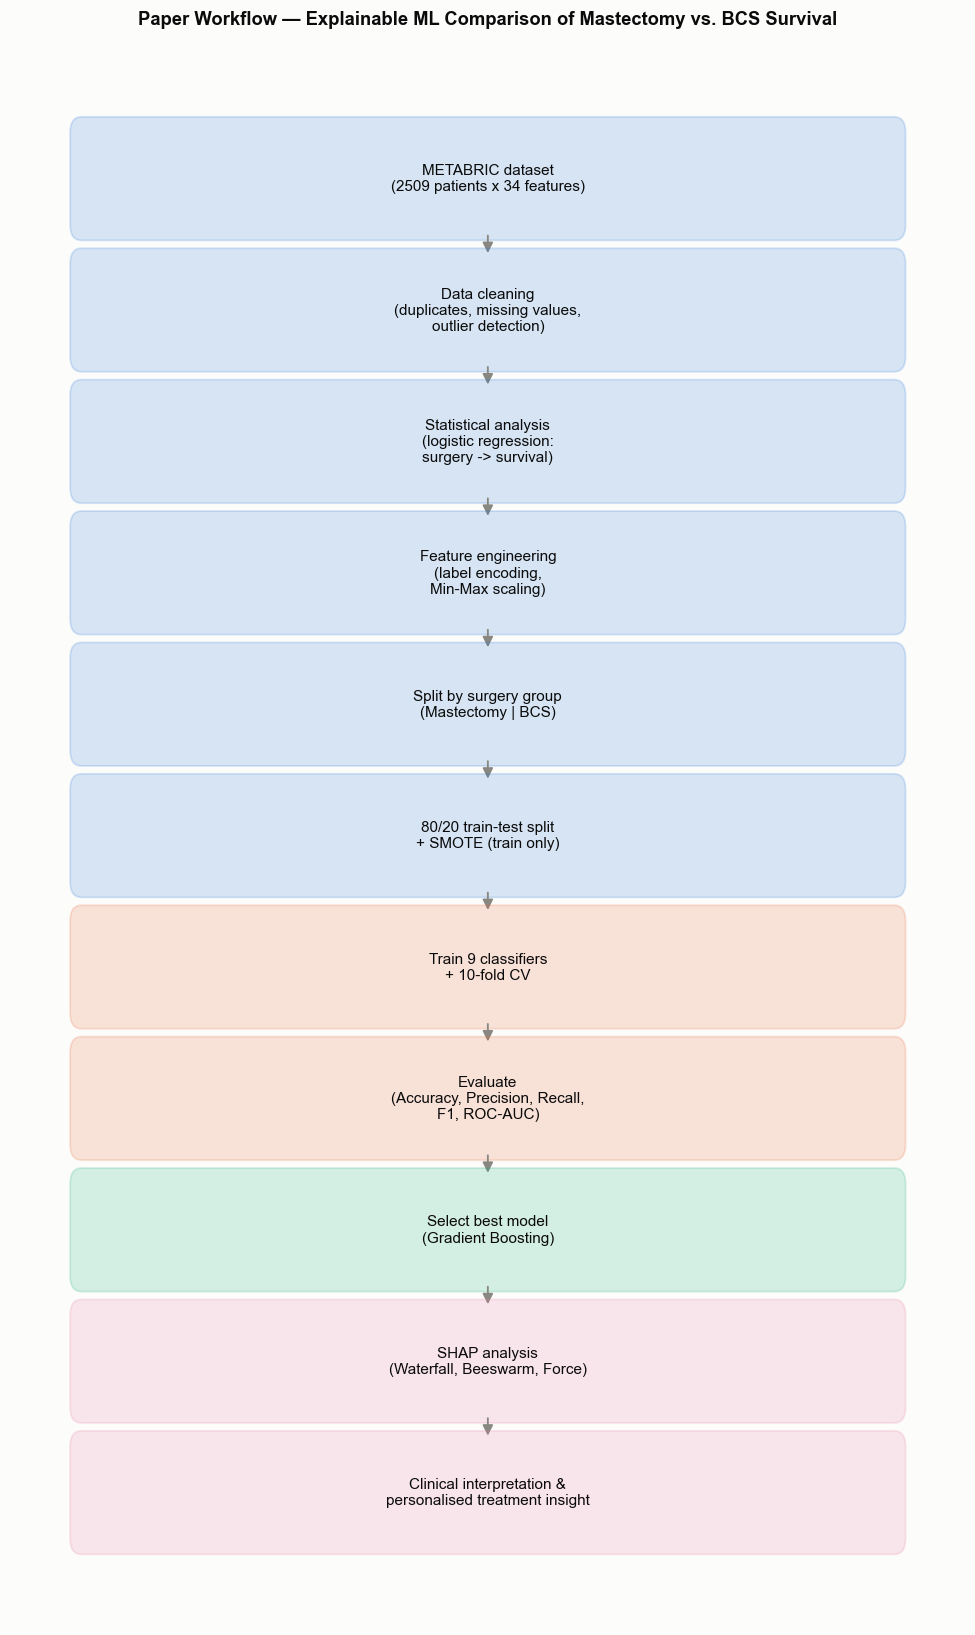

## 8. Algorithms used

| Category | Method |
|---|---|
| Missing-value imputation | Mode (categorical), KNN k=5 (numerical) |
| Outlier detection | IQR rule, Z-score |
| Statistical test | Logistic regression (surgery -> survival), t-test, chi-square |
| Encoding / scaling | Label encoding, Min-Max scaling |
| Class balancing | SMOTE |
| Classifiers | SVM, KNN, AdaBoost, Gradient Boosting, Random Forest, GaussianNB, Logistic Regression, XGBoost, Decision Tree |
| Cross-validation | 10-fold |
| Explainability | SHAP (TreeExplainer implied by tree-based best model): Waterfall, Beeswarm, Force plots |

## 9. Evaluation metrics

Accuracy, Precision, Recall, F1-score, and ROC-AUC, computed on both the training and held-out 20% test split, for every classifier, separately for the Mastectomy and BCS cohorts (Tables 2 & 3).

## 10. Figures in the paper

| Figure | Content |
|---|---|
| Fig. 1 | Class distribution of Overall Survival Status before/after SMOTE |
| Fig. 2 | SHAP Waterfall plots, Mastectomy (left) vs. BCS (right) |
| Fig. 3 | SHAP Beeswarm plots, Mastectomy (left) vs. BCS (right) |
| Fig. 4 | SHAP Force plot, Mastectomy |
| Fig. 5 | SHAP Force plot, BCS |

## 11. Tables in the paper

| Table | Content |
|---|---|
| Table 1 | Missing-value counts per feature, before and after imputation |
| Table 2 | Classifier performance (Accuracy, Precision, Recall, F1, ROC-AUC), Mastectomy, train & test |
| Table 3 | Classifier performance, BCS, train & test |

## 12. Strengths

- Directly compares two clinically-relevant surgical strategies using a large, well-characterised, publicly available cohort (METABRIC).
- Benchmarks nine classifiers rather than committing to a single algorithm a priori.
- Uses SHAP for per-surgery-group, per-patient explainability rather than a single pooled feature-importance ranking, surfacing clinically plausible effect reversals (e.g. Age/Menopausal State) between the two groups.
- Explicitly validates its imputation strategy statistically rather than assuming it is unbiased.
- Transparent about several of its own limitations (no feature-interaction modelling, retrospective dataset, SMOTE distributional risk, absence of imaging data).

## 13. Limitations (as identified by this reproduction, extending the paper's own "Limitations" section)

- **Likely data leakage**: `Relapse Free Status`, `Relapse Free Status (Months)`, `Overall Survival (Months)`, and especially `Patient's Vital Status` are included among the model's 34 candidate features without an explicit leakage discussion; several of these are near-tautologically related to the target (see Notebook 04's quantified leakage audit).
- **No formal time-to-event survival analysis** despite the paper's title and framing being built around "Overall Survival"; Kaplan-Meier, log-rank, and Cox modelling are absent (addressed in Notebook 08).
- **Unreported random seed** and incomplete hyperparameter specification for the "L2-regularised" Gradient Boosting model, limiting exact numerical reproducibility (addressed via Optuna tuning + documented defaults in Notebook 05).
- **Internal inconsistency** between the paper's Fig. 1 (2,007 patients pre-SMOTE) and Table 1 (2,509 - 528 = 1,981 patients) patient counts (documented and resolved in Notebook 02/09).
- **SMOTE-before/after-split ordering** not specified in the Methods text -- a common source of subtle test-set leakage if done incorrectly (we adopt and document the leakage-safe order in Notebook 04).
- **Small pseudo R²** (0.005) for the univariate surgery-survival logistic regression is acknowledged by the paper itself but arguably undersells how little surgery type alone explains, relative to the multivariable picture we build with Cox regression in Notebook 08.

## 14. Opportunities for reproduction

- Reconstruct the flat Kaggle CSV schema from the raw cBioPortal `brca_metabric` export (patient + sample clinical files), documenting every column mapping and the one necessary substitution (Mutation Count -> TMB non-synonymous).
- Quantify, rather than simply note, the leakage risk from `Patient's Vital Status` and related fields, and provide a leakage-free sensitivity analysis alongside the paper-faithful reproduction.
- Add the missing time-to-event survival analysis (Kaplan-Meier, log-rank, Cox PH, risk stratification).
- Extend the explainability toolkit beyond the paper's three SHAP plot types (dependence plots, permutation importance, partial dependence plots).
- Add modern hyperparameter optimisation (Optuna) and two additional gradient-boosting libraries (LightGBM, CatBoost) as points of comparison.
- Produce a fully modular, seeded, reproducible codebase (`src/`) and a complete, versioned artefact trail (figures, models, tables) -- none of which the original paper's Google-Colab-notebook workflow provides.

**Next:** Notebook 02 begins the hands-on reproduction with exploratory data analysis of the reconstructed METABRIC cohort.